# Infall Times:
<u>Main topics:</u>
* Create probability density functions (histograms) where the infall times are sorted into time bins, allowing us to see if/when the distribution of infall times is peaked and how it behaves across different mass ranges. It would be good to make one version that is not normalized to host formation time, and another that is. ✓
* Calculate the "preprocessed fraction," in other words the number of subhalos that fall onto something else before falling onto the MW, divided by the total number. ✓
* Create a plot using an autocorrelation function to measure how correlated the infall times of the "massive progenitor" are with the other subhalos (both field and associated I assume? This is the one I'm less clear on). It may also be useful to have a version that shows this effect but for different lines of sight. Autocorrelation should be giving a characteristic time interval for subhalo infalls. Cross-correlation function? d'Souza & Bell-like pair correlation function?
* Make a plot comparing the location/slope of the SHMF (before and after a particular massive infall), and the other side showing the change in the subhalo count of the massive infalls (GSE, LMC). Would be good to put side-by-side.

<u>Useful data fields:</u>
* t_infall_anything_bigger = time or snapshot when the subhalo under scrutiny falls into *any* more massive object (massive progenitor or main host). This would be "first_infall_snap" in the Symphony halo-level data (don't know where exactly yet).
* t_infall_main_host = time when the subhalo under scrutiny falls into *specifically* the main host. This would be "merger_snap" in the Symphony halo-level data, in the "hist" (time-independent) data.
* t_disrupt = time when the subhalo under scrutiny falls below the density required for ROCKSTAR to designate it a subhalo (300 particles)

In [1]:
## packages and globals

import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import astropy
from matplotlib import colormaps
import matplotlib.colors as mcolors
from symlib.util import DEFAULT_HALO_NAMES

from scipy.integrate import cumulative_trapezoid
from astropy.cosmology import FlatLambdaCDM

In [34]:
## GLOBALS:
base_dir = "C:/Users/steph/Symphony"                           ## base directory, points to the container folder where the Symphony data files are

## list of suites to be analyzed
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "EDEN_MilkyWay_8K", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#suite_list = ["EDEN_MilkyWay_8K"]

## colors for confidence band, individual hosts, etc
colors = {"SymphonyLMC": "tab:purple",
          "SymphonyMilkyWay": "tab:blue",
          "MWest": "black",
          "EDEN_MilkyWay_8K": "#5098f2",
          "SymphonyGroup": "tab:green",
          "SymphonyLCluster": "tab:orange",
          "SymphonyCluster": "tab:red"}

## colors for mean lines
avg_colors = {"SymphonyLMC": (102/225, 0/255, 110/255),
              "SymphonyMilkyWay": (7/255, 0/255, 110/255),
              "MWest": (0, 0, 0),
              "EDEN_MilkyWay_8K": (37/255, 107/255, 194/255),
              "SymphonyGroup": (22/255, 112/255, 0/255),
              "SymphonyLCluster": (163/255, 90/255, 2/255),
              "SymphonyCluster": (128/255, 3/255, 3/255)}

labels = {"SymphonyLMC": "SymphonyLMC",
          "SymphonyMilkyWay": "SymphonyMilkyWay",
          "MWest": "MWest",
          "EDEN_MilkyWay_8K": "EDEN_MilkyWay_8K",
          "SymphonyGroup": "SymphonyGroup",
          "SymphonyLCluster": "SymphonyLCluster",
          "SymphonyCluster": "SymphonyCluster"}

The function "load_infall_data" below is supposed to read in subhalo infall times, sorted into two categories:
1. Infall times corresponding to when subhalos fell into specifically the *main host.* This includes subhalos that fell into a larger subhalo before falling into the main host. This field is read in using hist["merger_snap"]
2. Infall times corresponding to when subhalos fell into *any halo larger than themselves.*

Prior to sorting, subhalos are also filtered using a 300 particle mass cut to reduce noise, and are also checked that they exist at the infall snapshot using the "ok" filter. To check that these cuts are working, the function also spits out how many subhalos were removed by the filter on a per-host and a per-suite basis.

In [35]:
## SUBHALO INFALL DATALOADER FUNCTION:
## key quantities:
## merger_snap         --> first infall into main host
## first_infall_snap   --> first infall into ANY halo larger than itself

def load_infall_data(base_dir, suite_list, colors, avg_colors, labels):

    suite_data = {}

    for suite in suite_list:
        
        print(f"\n\033[1mCurrent suite: {suite}\033[0m")

        halo_names = DEFAULT_HALO_NAMES[suite]

        ## reading in a global set of scale factors for this suite
        sim_dir0 = symlib.get_host_directory(base_dir, suite, 0)
        scale_factors = symlib.scale_factors(sim_dir0)
        params = symlib.simulation_parameters(sim_dir0)
        nbins_suite = len(scale_factors)

        ## converting from scale factors to cosmic time, for later
        ## to do this, we need to get the cosmological parameters from the Symphony simulation parameters
        Om0 = params["Om0"]
        H0 = params["H0"]

        ## astropy has a function to automatically convert from scale factor to cosmic time
        ## scale factors are the same for all hosts in a given suite, so we only have to do this once per suite
        cosmo = FlatLambdaCDM(H0 = H0, Om0 = Om0)
        times = cosmo.age(1/scale_factors - 1).value    ## time in Gyr
        
        print(f"\n\033[1mAge of universe from conversion:\033[0m {times[-1]} Gyr")
        
        print("\nMin/Max dt:")
        print(np.min(np.diff(times)))
        print(np.max(np.diff(times)))

        ## storing the per-host data
        hosts = []

        print(f"\n\033[1mStarting halo data read-in process:\033[0m")
        
        for halo_index, halo_name in enumerate(halo_names):
            print(f"\nHalo {halo_index + 1}/{len(halo_names)}: {halo_name}", end = "\r", flush = True)

            ## try-except block needed to catch corrupted data in EDEN_MilkyWay-8K
            try:

                sim_dir = symlib.get_host_directory(base_dir, suite, halo_name)
                h, hist = symlib.read_subhalos(sim_dir)
                params = symlib.simulation_parameters(sim_dir)
    
                ## basic quantities: particle mass, virial mass, "ok" array, and "MAIN HOST" & "ANYTHING LARGER" INFALL DATA:
                mp = params["mp"]                                 ## particle mass used for this suite
    
                ## snapshot-space infalls
                host_infall_snap = hist["merger_snap"]            ## when subhalos fell into the main host
                first_infall_snap = hist["first_infall_snap"]     ## when subhalos fell into anything more massive than itself
                
                mvir = h["mvir"]     ## shape (# of subhalos, # of snapshots)
                ok = h["ok"]         ## shape (# of subhalos, # of snapshots)
    
                
                ## MAIN HOST INFALL:
                ## keep only subhalos which:
                ## 1. have valid infall snapshot (not interested in the main host behavior at the moment)
                ## 2. have infall mass greater than >= 300 particle masses
                ## 3. exist AT the infall snapshot (as determined by Rockstar/Symlib)
    
                ## removing the main host (always at snap = 0, biases results)
                host_infall_no_main = host_infall_snap > 0                                       ## removing the main host
                host_infall_rows_no_main = np.where(host_infall_no_main)[0]                      ## subhalo indices, excluding the main host
                host_infall_snaps_no_main = host_infall_snap[host_infall_no_main].astype(int)    ## subhalo infall snapshots, excluding the main host
    
                ## mass cut, removing subhalos below a 300 particle mass resolution limit
                mass_cut = mvir[host_infall_rows_no_main, host_infall_snaps_no_main] >= 300 * mp
                host_infall_rows_mass_ok = host_infall_rows_no_main[mass_cut]
                host_infall_snaps_mass_ok = host_infall_snaps_no_main[mass_cut]
    
                ## subhalo survival cut: does the subhalo exist AT the infall snapshot?
                ok_cut = ok[host_infall_rows_mass_ok, host_infall_snaps_mass_ok]
                host_infall_rows_ok = host_infall_rows_mass_ok[ok_cut]
                host_infall_snaps_ok = host_infall_snaps_mass_ok[ok_cut]
    
                ## INFALL INTO ANYTHING LARGER (conditional on the host):
                first_infall_snaps_sel = first_infall_snap[host_infall_rows_ok].astype(int)
    
                valid = np.isfinite(host_infall_snaps_ok) & np.isfinite(first_infall_snaps_sel)
    
                host_infall_snaps_ok = host_infall_snaps_ok[valid]
                host_infall_rows_ok = host_infall_rows_ok[valid]
                first_infall_snaps_sel = first_infall_snaps_sel[valid]
    
                ## CONVERT FROM SNAPSHOT TO COSMIC TIME:
                host_infall_time = times[host_infall_snaps_ok]
                first_infall_time = times[first_infall_snaps_sel]
    
                # lookback time:
                t_now = times[-1]
                host_infall_tlb = t_now - host_infall_time
                first_infall_tlb = t_now - first_infall_time
                
                
                ## PREPROCESSING FRACTIONS:
                ## of this sample of subhalos that are NOT the main host, are above the 300 particle limit, AND are marked as "ok" by the halo finders,
                ## how many of them fell into something larger before falling into the main host?
                ## a subhalo is "preprocessed" if first_infall_snap < host_infall_snap
                ## we also want to construct time-series data f(t) --> the fraction of subhalos that were preprocessed by time (snapshot) t
    
                ## preprocessing label:
                is_preprocessed = first_infall_snaps_sel < host_infall_snaps_ok
    
                ## AUTOCORRELATION EVENT ARRAYS
    
                ## now building the time series information we need for the autocorrelation:
                infall_events = np.zeros(nbins_suite)
                preprocessed_events = np.zeros(nbins_suite)
                
                # valid bin range
                valid_bins = (host_infall_snaps_ok >= 0) & (host_infall_snaps_ok < nbins_suite)
    
                ## binning & accumulation (vectorized):
                host_bins = host_infall_snaps_ok[valid_bins]
                pre_bins = is_preprocessed[valid_bins].astype(int)
    
                ## total infall events & subset that are preprocessed
                np.add.at(infall_events, host_bins, 1)
                np.add.at(preprocessed_events, host_bins, pre_bins)
    
                ## convert to fraction (for diagnostics):
                preprocessing_fraction_t = np.full(nbins_suite, np.nan)
                mask = infall_events > 0
                preprocessing_fraction_t[mask] = preprocessed_events[mask] / infall_events[mask]
    
                preprocessing_fraction_scalar = np.nanmean(preprocessing_fraction_t)
                
                print(f"\nPer-halo PREPROCESSING FRACTION:")
                print(f"Mean Preprocessed fraction: {preprocessing_fraction_scalar:.4f}")
                print(f"\n##############################################################################################################################")
    
    
                ## NORMALIZATION USING A50:
                host_mvir = mvir[0, :]                                ## getting the host peak mass
                peak_mass = np.max(host_mvir)
                cross = np.where(host_mvir >= 0.5 * peak_mass)[0]     ## finding the snapshot when the host crossed over its 50% peak mass threshold
    
                ## SAFE NORMALIZATION
                if len(cross) == 0:
                    a50 = np.nan
                    t50 = np.nan
                else:
                    a50 = scale_factors[cross[0]]
                    t50 = times[cross[0]]
    
                ## normalizing time by t50
                if np.isfinite(t50):
                    host_infall_time_norm = host_infall_time - t50
                    first_infall_time_norm = first_infall_time - t50
                else:
                    host_infall_time_norm = np.full_like(host_infall_time, np.nan)
                    first_infall_time_norm = np.full_like(first_infall_time, np.nan)
    
                
                ## COUNTS: counting up # of subhalos per time bin
                
                host_infall_counts = np.zeros(nbins_suite)
                first_infall_counts = np.zeros(nbins_suite)
    
                if len(host_infall_snaps_ok) > 0:
                    u, c = np.unique(host_infall_snaps_ok, return_counts = True)
                    host_infall_counts[u] = c
                
                if len(first_infall_snaps_sel) > 0:
                    u, c = np.unique(first_infall_snaps_sel, return_counts = True)
                    first_infall_counts[u] = c
    
    
                ## STORING HOST DATA
                host_data = {
    
                    # snapshot-space
                    "host_infall_snaps_ok": host_infall_snaps_ok,
                    "host_infall_rows_ok": host_infall_rows_ok,
                    "first_infall_snaps_sel": first_infall_snaps_sel,
    
                    # scale factor space
                    "host_infall_sf": scale_factors[host_infall_snaps_ok],
                    "first_infall_sf": scale_factors[first_infall_snaps_sel],
    
                    "host_infall_sf_norm": scale_factors[host_infall_snaps_ok] / a50 if np.isfinite(a50) else np.nan,
                    "first_infall_sf_norm": scale_factors[first_infall_snaps_sel] / a50 if np.isfinite(a50) else np.nan,
    
                    # NEW: time-space (what you actually want)
                    "host_infall_time": host_infall_time,
                    "first_infall_time": first_infall_time,
    
                    "host_infall_tlb": host_infall_tlb,
                    "first_infall_tlb": first_infall_tlb,
                    
                    # t50
                    "host_infall_time_norm": host_infall_time_norm,
                    "first_infall_time_norm": first_infall_time_norm,
    
                    # counts
                    "host_infall_counts": host_infall_counts,
                    "first_infall_counts": first_infall_counts,
    
                    # preprocessing
                    "is_preprocessed": is_preprocessed,
                    "infall_events": infall_events,
                    "preprocessed_events": preprocessed_events,
                    "preprocessing_fraction": preprocessing_fraction_scalar,
                    "preprocessing_fraction_t": preprocessing_fraction_t,
    
                    # host properties
                    "host_mass": peak_mass,
                    "a50": a50,
                    "t50": t50}
    
                hosts.append(host_data)

            except Exception as e:
                print(f"\nSkipping halo {halo_index} in {suite}: {e}")
                continue

        ## STORING PER-SUITE DATA
        suite_data[suite] = {"scale_factors": scale_factors,
                             "times": times,
                             "hosts": hosts}

        print(f"\nSUITE PREPROCESSING SUMMARY")
        
        fractions = [h["preprocessing_fraction"] for h in hosts]
        print(f"Mean per-halo fraction:   {(np.mean(fractions) * 100):.2f}%")
        print(f"Median per-halo fraction: {(np.median(fractions) * 100):.2f}%")

        print(f"\nFinished suite: {suite} ({len(hosts)} halos)")
        print(f"========================================================================================================================")

    return suite_data

In [36]:
## load data once
suite_data = load_infall_data(base_dir, suite_list, colors, avg_colors, labels)


Current suite: SymphonyLMC

Age of universe from conversion: 13.647485185443239 Gyr

Min/Max dt:
0.003758078845689128
0.17660077088716086

Starting halo data read-in process:

Halo 1/39: Halo032
Per-halo PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.2671

##############################################################################################################################

Halo 2/39: Halo059
Per-halo PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.4396

##############################################################################################################################

Halo 3/39: Halo0662
Per-halo PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.2969

##############################################################################################################################

Halo 4/39: Halo083
Per-halo PREPROCESSING FRACTION:
Mean Preprocessed fraction: 0.2054

######################################################################################

Now defining some functions to plot this infall data in various ways:
1. Row 1 is simply a histogram of the subhalo infall data, sorted into snapshot bins. The solid line is for the host infall data, and the dashed line is for the "anything larger" infall data.
2. Row 2 is a PDF of the subhalo infall data (basically Row 1 but normalized so that the total probability = 100%).
3. Row 3 is a CDF of the subhalo infall data (showing the "fraction of the total").
4. Row 4 is Row 2, normalized to the time (snapshot) when the main host accumulated 50% of its peak mass.
5. Row 5 is Row 3, normalized to the time (snapshot) when the main host accumulated 50% of its peak mass.

In [37]:
## functions to plot the raw, un-normalized data

def compute_raw_counts_stats(raw_counts):
    
    mean = np.mean(raw_counts, axis = 0)
    p16_raw = np.percentile(raw_counts, 16, axis = 0)
    p84_raw = np.percentile(raw_counts, 84, axis = 0)

    return mean, p16_raw, p84_raw

def plot_raw_counts(ax, x, raw_counts, color, fill = False, label = None):

    mean, p16_raw, p84_raw = compute_raw_counts_stats(raw_counts)
    
    ax.plot(x, mean, color = color, lw = 2)
    
    if fill:
        ax.fill_between(x, p16_raw, p84_raw, color = color, alpha = 0.25)

#######################################################################################################################

## PDF HELPER FUNCTIONS
def compute_pdf(values, bins):

    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return None, None

    hist, edges = np.histogram(values, bins = bins, density = True)

    centers = 0.5 * (edges[:-1] + edges[1:])

    return centers, hist

def compute_pdf_stats_hosts(hosts, key, bins, mask_fn = None):

    pdf_stack = []
    centers = None

    for h in hosts:

        values = np.asarray(h[key])

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]

        if len(values) == 0:
            continue

        c, pdf = compute_pdf(values, bins)

        if pdf is None:
            continue

        centers = c
        pdf_stack.append(pdf)

    pdf_stack = np.asarray(pdf_stack)

    if len(pdf_stack) == 0:
        return None, None, None, None

    mean = np.mean(pdf_stack, axis=0)
    p16  = np.percentile(pdf_stack, 16, axis = 0)
    p84  = np.percentile(pdf_stack, 84, axis = 0)

    return centers, mean, p16, p84


def plot_pdf_hosts(ax, hosts, key, bins, color, fill = False, mask_fn = None, label = None):

    centers, mean, p16, p84 = compute_pdf_stats_hosts(hosts, key, bins, mask_fn)

    if mean is None:
        return

    ax.plot(centers, mean, color = color, lw = 2, label = label)

    if fill:
        ax.fill_between(centers, p16, p84, color = color, alpha = 0.25)

#######################################################################################################################

## CDF HELPER FUNCTIONS
def compute_cdf(values, grid):

    values = np.sort(values)
    if len(values) == 0:
        return np.zeros_like(grid)

    cdf = np.arange(1, len(values) + 1) / len(values)
    return np.interp(grid, values, cdf, left = 0, right = 1)


def compute_cdf_stats_hosts(hosts, key, grid, mask_fn = None):

    cdf_stack = []

    for h in hosts:

        values = h[key]

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue

        cdf_stack.append(compute_cdf(values, grid))

    cdf_stack = np.array(cdf_stack)

    if len(cdf_stack) == 0:
        return None, None, None

    mean = np.mean(cdf_stack, axis = 0)
    p16  = np.percentile(cdf_stack, 16, axis = 0)
    p84  = np.percentile(cdf_stack, 84, axis = 0)

    return mean, p16, p84

## function to plot the CDFs
def plot_cdf_hosts(ax, hosts, key, grid, color, fill = False, mask_fn = None, label = None):

    mean, p16, p84 = compute_cdf_stats_hosts(hosts, key, grid, mask_fn)

    if mean is None:
        return

    ax.plot(grid, mean, color = color, lw = 2, label = label)
    
    if fill:
        ax.fill_between(grid, p16, p84, color = color, alpha = 0.25)

SymphonyLMC
SymphonyMilkyWay
MWest
EDEN_MilkyWay_8K
SymphonyGroup
SymphonyLCluster
SymphonyCluster


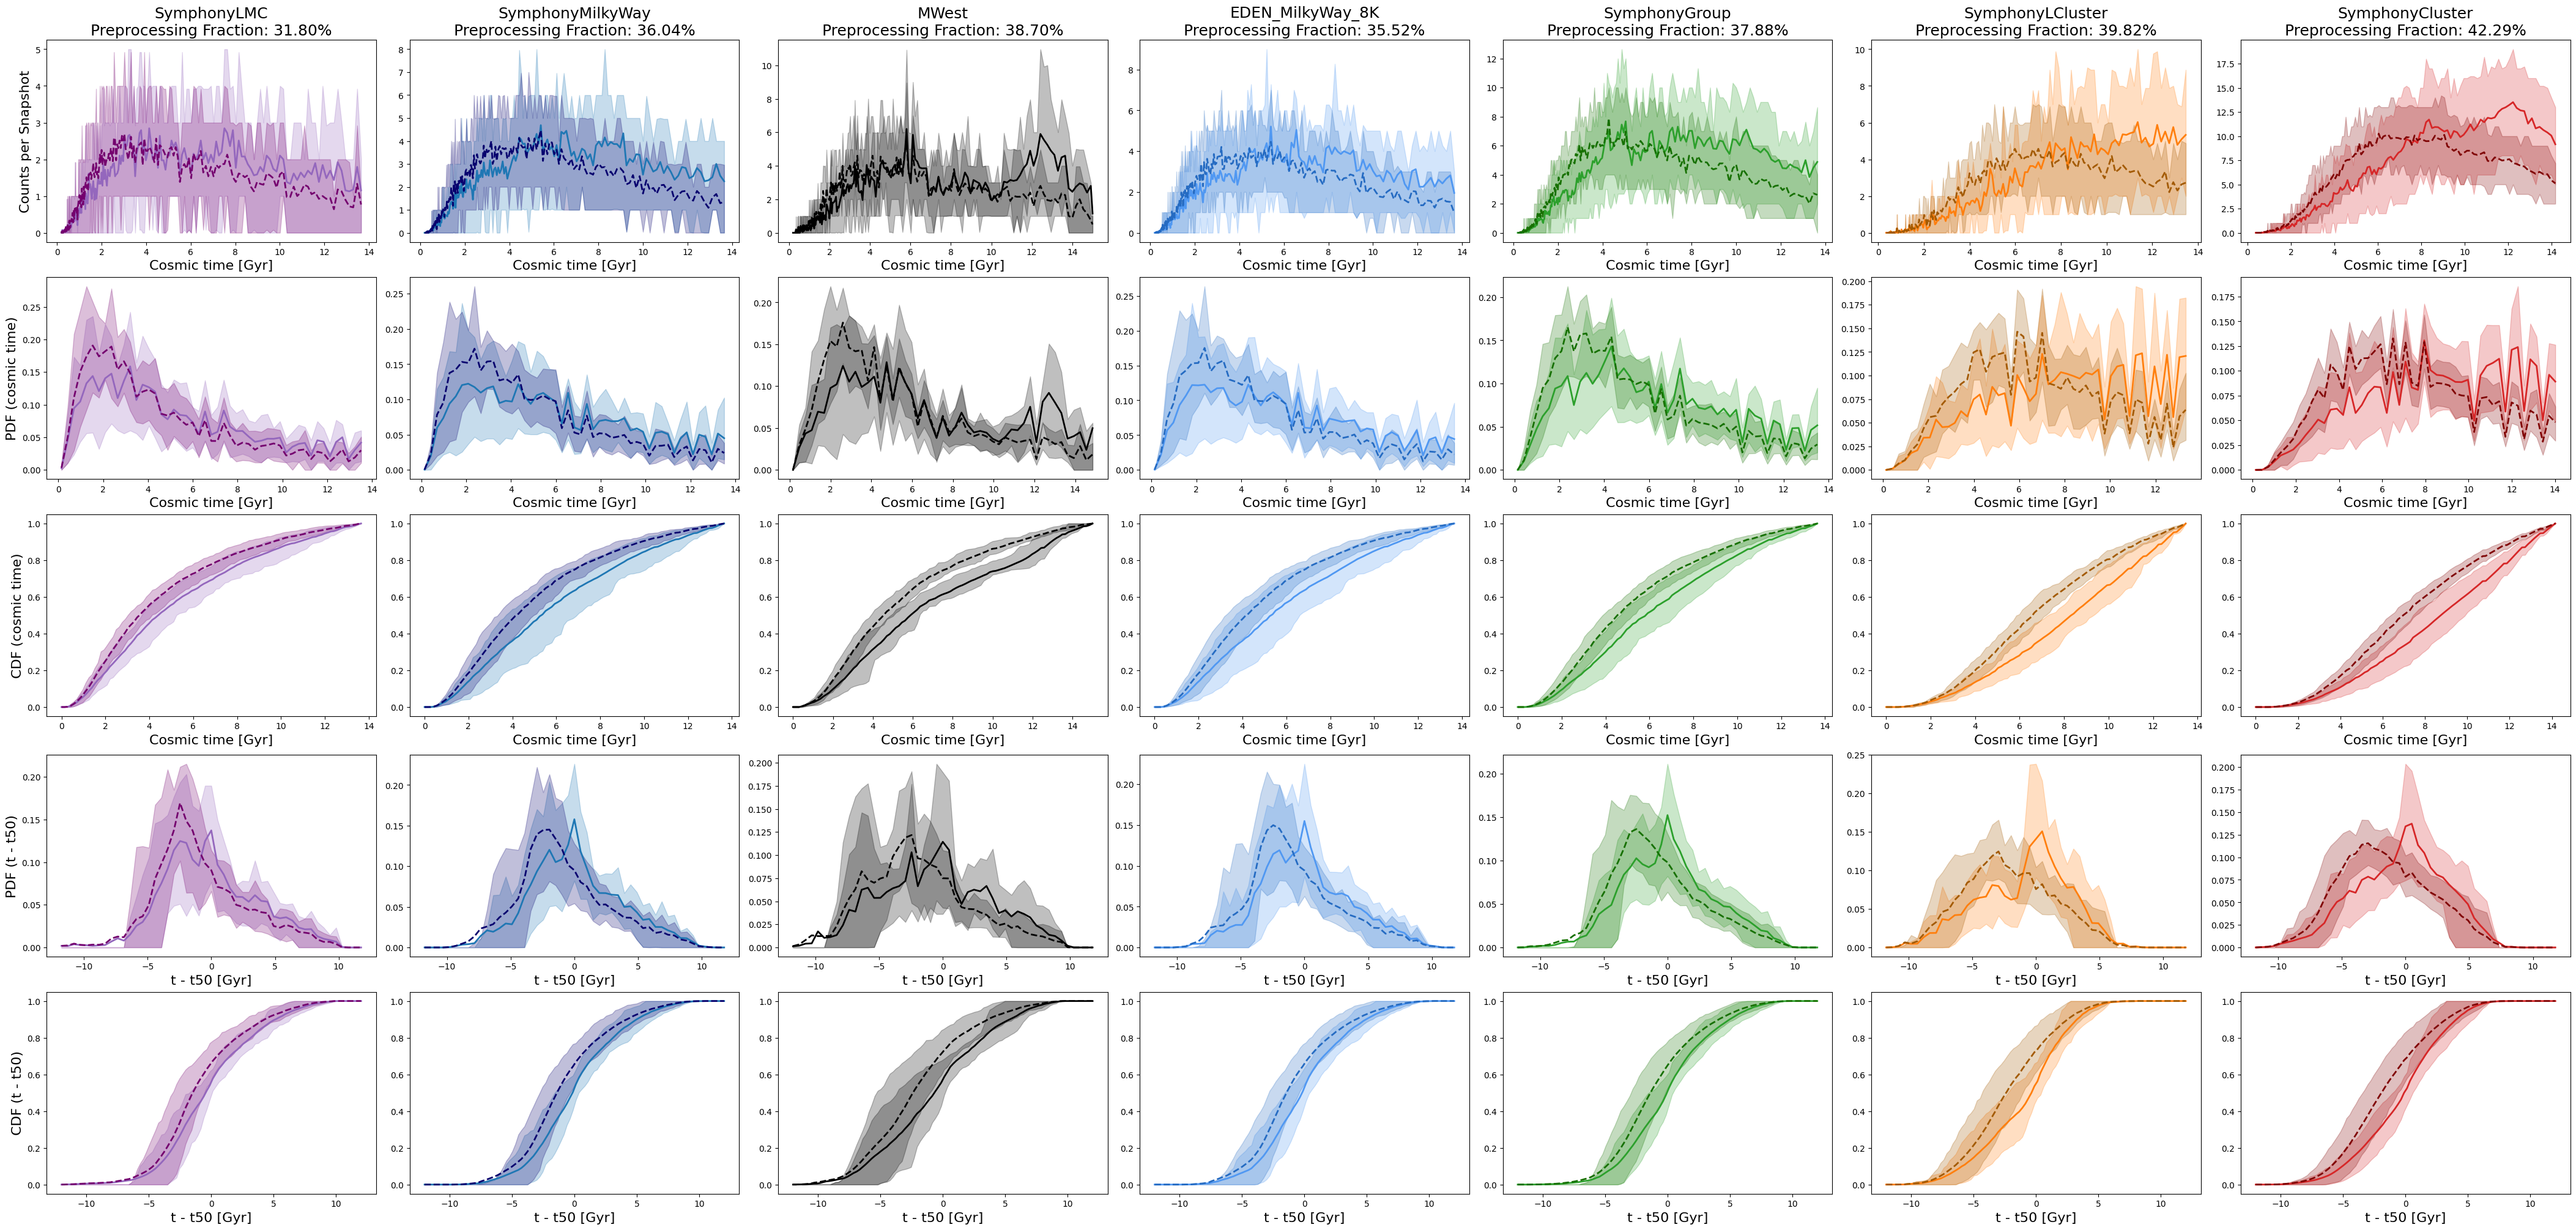

In [40]:
## FULL INFALL FIGURE
## Solid lines  --> main host infall
## Dashed lines --> first infall into ANY larger halo

def make_infall_figure_full(suite_data, suite_list, colors, avg_colors, fill):

    nrows = 5
    ncols = len(suite_list)

    fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (6 * ncols, 4 * nrows), constrained_layout = True, squeeze = False)

    for i, suite in enumerate(suite_list):

        data = suite_data[suite]
        color = colors[suite]
        avg_color = avg_colors[suite]
        
        scale_factors = data["scale_factors"]
        hosts = data["hosts"]
        times = data["times"]

        ## defining time bins and grids
        t_bins = np.linspace(0, times[-1], 50)
        t_grid = np.linspace(0, times[-1], 100)
        trel_bins = np.linspace(-12, 12, 50)
        trel_grid = np.linspace(-12, 12, 100)

        ## preprocessing statistics:
        fractions = np.array([h["preprocessing_fraction"] for h in hosts])
        frac_mean = np.mean(fractions)
        frac_median  = np.median(fractions)

#######################################################################################################################

        ## ROW 1: RAW COUNTS
        ## gettings raw counts data:
        host_infall_counts = np.array([h["host_infall_counts"] for h in hosts])
        first_infall_counts = np.array([h["first_infall_counts"] for h in hosts])

        # main-host infall
        plot_raw_counts(ax[0, i], times, host_infall_counts, color = color, fill = fill)

        # first infall into any host
        plot_raw_counts(ax[0, i], times, first_infall_counts, color = avg_color, fill = fill)
        ax[0, i].lines[-1].set_linestyle("--")    # making the "into anything bigger" line dashed

#######################################################################################################################

        ## ROW 2: RAW PDF --> "At what cosmic times does the average halo tend to infall?"

        ## same format as before: main host infalls as solid lines, then any-host infalls as dashed lines
        plot_pdf_hosts(ax[1, i], hosts, key = "host_infall_time", bins = t_bins, color = color, fill = fill)
        plot_pdf_hosts(ax[1, i], hosts, key = "first_infall_time", bins = t_bins, color = avg_color, fill = fill)
        ax[1, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## ROW 3: RAW CDF --> "By time t, what fraction of all infall events have already occurred?"

        ## you get the gist
        plot_cdf_hosts(ax[2, i], hosts, key = "host_infall_time", grid = t_grid, color = color, fill = fill)
        plot_cdf_hosts(ax[2, i], hosts, key = "first_infall_time", grid = t_grid, color = avg_color, fill = fill)
        ax[2, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## ROW 4: NORMALIZED PDF --> "Do infalls tend to happen before or after the host reaches half its peak mass?"
        print(suite)
        #print(np.min([np.min(h["host_infall_time_norm"]) for h in hosts]))
        #print(np.max([np.max(h["host_infall_time_norm"]) for h in hosts]))

        plot_pdf_hosts(ax[3, i], hosts, key = "host_infall_time_norm", bins = trel_bins, color = color, fill = fill)
        plot_pdf_hosts(ax[3, i], hosts, key = "first_infall_time_norm", bins = trel_bins, color = avg_color, fill = fill)
        ax[3, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## ROW 5: NORMALIZED CDF --> "Fraction of infalls occurring before/after formation epoch?"

        plot_cdf_hosts(ax[4, i], hosts, key = "host_infall_time_norm", grid = trel_grid, color = color, fill = fill)
        plot_cdf_hosts(ax[4, i], hosts, key = "first_infall_time_norm", grid = trel_grid, color = avg_color, fill = fill)
        ax[4, i].lines[-1].set_linestyle("--")

#######################################################################################################################

        ## AXIS LIMITS AND LABELS:
        ax[0, i].set_title(f"{suite}\nPreprocessing Fraction: {(frac_mean * 100):.2f}%", fontsize = 18)

    ## y-axis labels
    ax[0, 0].set_ylabel("Counts per Snapshot", fontsize = 16)
    ax[1, 0].set_ylabel("PDF (cosmic time)", fontsize = 16)
    ax[2, 0].set_ylabel("CDF (cosmic time)", fontsize = 16)
    ax[3, 0].set_ylabel("PDF (t - t50)", fontsize = 16)
    ax[4, 0].set_ylabel("CDF (t - t50)", fontsize = 16)

    ## x-labels
    for j in range(ncols):
        ax[0, j].set_xlabel("Cosmic time [Gyr]", fontsize = 16)
        ax[1, j].set_xlabel("Cosmic time [Gyr]", fontsize = 16)
        ax[2, j].set_xlabel("Cosmic time [Gyr]", fontsize = 16)
        ax[3, j].set_xlabel("t - t50 [Gyr]", fontsize = 16)
        ax[4, j].set_xlabel("t - t50 [Gyr]", fontsize = 16)
    

    return fig, ax

## entrypoint:

## make plotting adjustments as needed
fig, ax = make_infall_figure_full(suite_data, suite_list, colors, avg_colors, fill = True)

#fig.savefig("Infalls (cosmic time using astropy) + EDEN.png", bbox_inches = "tight")
plt.show()

Now looking at how subhalo infalls are clustered around the infall time of a "massive progenitor."
* Identify a "massive progenitor" subhalo (significant fraction of the host mass, say 5-10%)
* Find the time (snapshot, converted to cosmic time) when this massive subhalo falls into the host
* Find all the subhalos that are "associated" with this massive progenitor (using the Deason et. al. criterion from [d'Souza & Bell 2021](https://arxiv.org/pdf/2104.13249) or otherwise) and find the times that they fell into the main host
* Reorganize so that the massive progenitor falls in at time t = 0, and other subhalo infalls are defined relative to that time (basically just subtracting the infall time of the massive progenitor)

Suite SymphonyLMC --> z = 10.0 cutoff: snapshot 47, cosmic time 0.48 Gyr
Mean snapshot spacing: 57.2 Myr --> 17 snapshots ~ 1 Gyr
Loading host 38 in suite SymphonyLMC
Suitewide mean for suite SymphonyLMC: 48.09% | Suitewide Median for suite SymphonyLMC: 48.66%
Suite SymphonyMilkyWay --> z = 10.0 cutoff: snapshot 47, cosmic time 0.48 Gyr
Mean snapshot spacing: 57.2 Myr --> 17 snapshots ~ 1 Gyr
Loading host 44 in suite SymphonyMilkyWay
Suitewide mean for suite SymphonyMilkyWay: 49.35% | Suitewide Median for suite SymphonyMilkyWay: 49.93%
Suite MWest --> z = 10.0 cutoff: snapshot 47, cosmic time 0.48 Gyr
Mean snapshot spacing: 60.9 Myr --> 16 snapshots ~ 1 Gyr
Loading host 19 in suite MWest
Suitewide mean for suite MWest: 51.72% | Suitewide Median for suite MWest: 48.36%
Suite EDEN_MilkyWay_8K --> z = 10.0 cutoff: snapshot 47, cosmic time 0.48 Gyr
Mean snapshot spacing: 57.2 Myr --> 17 snapshots ~ 1 Gyr
Loading host 0 in suite EDEN_MilkyWay_8K
Skipping host 0 in EDEN_MilkyWay_8K: [Errno 2

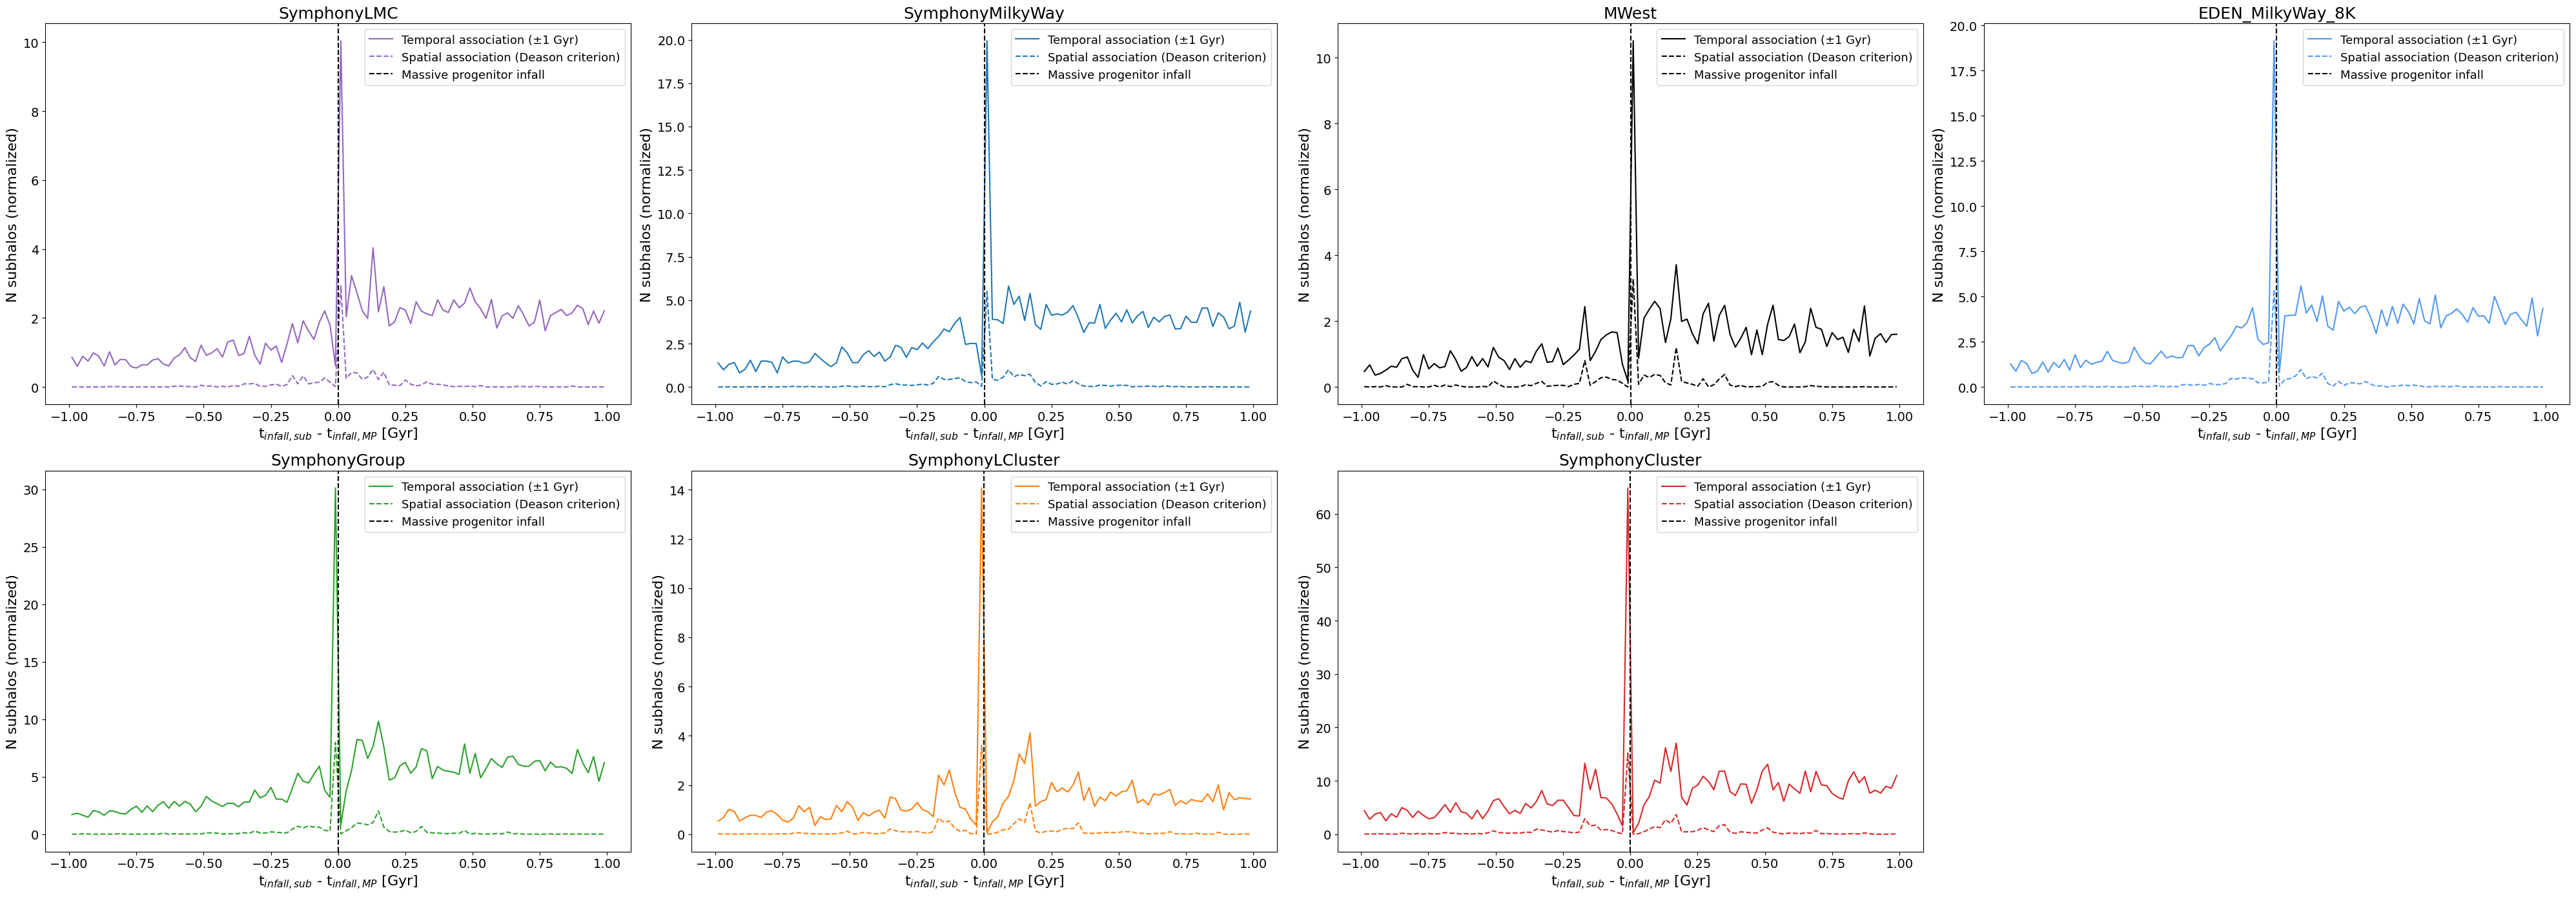

In [52]:
## basic pipeline (very rough)

n_suites = len(suite_list)
n_cols = min(n_suites, 4)
n_rows = int(np.ceil(n_suites / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize = (10 * n_cols, 7 * n_rows), sharey = False)
axes = np.array(axes).flatten()   ## ensure axes is always iterable

for suite_index, suite_name in enumerate(suite_list):
    
    n_hosts = symlib.n_hosts(suite_name)
    
    sim_dir_0 = symlib.get_host_directory(base_dir, suite_name, 0)
    params = symlib.simulation_parameters(sim_dir_0)

    ## these parameters are the same for every host in a given suite
    H0 = params["H0"]
    Om0 = params["Om0"]
    little_h = H0 / 100
    cosmo = FlatLambdaCDM(H0 = H0, Om0 = Om0)

    ## compute scale factors and cosmic times once per suite using the first host
    scale_factors_0 = symlib.scale_factors(sim_dir_0)
    cosmic_times_0 = cosmo.age(1/scale_factors_0 - 1).value

    # z cutoff --> subhalos infalling before this are likely unreliable
    z_cutoff = 10.0
    t_cutoff = cosmo.age(z_cutoff).value   # in Gyr
    min_infall_snap = np.searchsorted(cosmic_times_0, t_cutoff)
    print(f"Suite {suite_name} --> z = {z_cutoff} cutoff: snapshot {min_infall_snap}, cosmic time {t_cutoff:.2f} Gyr")

    ## find how many snapshots correspond to 1 Gyr in this suite
    dt_snaps = np.diff(cosmic_times_0)
    dt_mean = np.mean(dt_snaps)   ## mean snapshot spacing in Gyr
    n_snaps_1gyr = max(1, int(np.round(1.0 / dt_mean)))
    print(f"Mean snapshot spacing: {dt_mean*1000:.1f} Myr --> {n_snaps_1gyr} snapshots ~ 1 Gyr")

    avg_infall_mass_fraction = []
    all_offsets_temporal = []         ## primary criterion: temporal association (+/- 1 Gyr)
    all_offsets_spatial = []          ## secondary criterion: spatial association (Deason et. al. 2015)
    
    for i_host in range(n_hosts):

        print(f"Loading host {i_host} in suite {suite_name}", end = "\r", flush = True)

        ## try-except block to catch corrupted or missing halos (such as in EDEN)
        try:
    
            ## reading in the data like normal
            sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
            scale_factors = symlib.scale_factors(sim_dir)
            #snapshots = np.arange(0, len(scale_factors), 1)
    
            ## using astropy to convert from scale factors to cosmic times
            cosmic_times = cosmo.age(1/scale_factors - 1).value    ## returns times in Gyr
    
            ## reading in subhalo data
            h, hist = symlib.read_subhalos(sim_dir)
    
            ## to start, let's just say that the "massive progenitor" is the next most massive subhalo after the host AT THE TIME OF INFALL
            ## reusing our logic from before, we can use "merger_snap" to get host infall snapshots for all subhalos --. convert to cosmic time
            infall_snaps = hist["merger_snap"]
            infall_times_gyr = np.array([cosmic_times[s] if s >= 0 else np.nan for s in infall_snaps])
    
            ## getting the mass of each subhalo at its infall snapshot
            mass_at_infall = np.array([h["mvir"][i, infall_snaps[i]] if infall_snaps[i] >= 0 else 0 for i in range(len(infall_snaps))])
            mass_at_infall[0] = 0   # exclude host from ranking
    
            ## getting the host mass at the infall snaps of each subhalo
            host_mass_at_infall_snap = np.array([h["mvir"][0, infall_snaps[i]] if infall_snaps[i] >= 0 else np.nan for i in range(len(infall_snaps))])
            mass_fraction_at_infall = mass_at_infall / host_mass_at_infall_snap

            ## massive progenitor selection:
            ## keep subhalos with >= 1/10th of the host mass at infall, excluding unphysical cases (fraction >= 1), and
            ## early unreliable snapshots (before z_cutoff)
            deason_mask = ((mass_fraction_at_infall >= 0.1) & (mass_fraction_at_infall < 1.0) & (infall_snaps >= min_infall_snap))
            deason_mask[0] = False                              ## exclude host explicitly
            massive_progenitors = np.where(deason_mask)[0]      ## getting indices 
    
            ## for each massive progenitor, find temporally associated subhalos (within +/- 1 Gyr of massive progenitor host infall)
            for mp_idx in massive_progenitors:
                mp_infall_snap = infall_snaps[mp_idx]
                mp_infall_time = infall_times_gyr[mp_idx]

                ## compute infall time offsets relative to when the massive progenitor fell in
                offsets = infall_times_gyr - mp_infall_time

                ## PRIMARY CRITERION --> TEMPORAL ASSOCIATION:
                ## keep subhalos accreted within +/- 1 Gyr of the massive progenitor's infall
                temporal_mask = np.abs(offsets) <= 1.0
                temporal_mask[0] = False                    ## explicitly exclude the host
                temporal_mask[mp_idx] = False               ## explicitly exclude the massive progenitor itself
                temporally_associated = np.where(temporal_mask)[0]
                all_offsets_temporal.extend(offsets[temporally_associated])

                ## SECONDARY CRITERION --> SPATIAL ASSOCIATION:
                ## subset of temporal associations that were inside the massive progenitor's virial radius for at least
                ## 2 consecutive snapshots (1 Gyr) before crossing the main host virial radius
                mp_pos = h["x"][mp_idx, :, :]   ## shape (n_snaps, 3) in comoving coordinates
                mp_rvir = h["rvir"][mp_idx, :]  ## shape (n_snaps, 1) in units of h^-1 kpc

                for sub_idx in temporally_associated:
                    sub_infall_snap = infall_snaps[sub_idx]
                    if sub_infall_snap < n_snaps_1gyr:
                        continue

                    ## scan snapshots before the subhalo crossed the main host virial radius,
                    ## looking for at least n_snaps_1gyr consecutive snapshots inside the MP virial radius
                    consecutive_count = 0
                    for snap in range(sub_infall_snap - 1, max(sub_infall_snap - 20, 0), -1):
                        a = scale_factors[snap]

                        ## convert comoving coordinates to physical kpc
                        sub_pos_phys = h["x"][sub_idx, snap, :] * a / little_h   ## physical kpc
                        mp_pos_phys = mp_pos[snap, :] * a / little_h             ## physical kpc

                        ## convert MP virial radius from h^-1 kpc to physical kpc
                        mp_rvir_phys = mp_rvir[snap] * a / little_h              ## physical kpc

                        ## 3D distance between subhalo and massive progenitor
                        dist = np.sqrt(np.sum((sub_pos_phys - mp_pos_phys)**2))

                        if dist < mp_rvir_phys:
                            consecutive_count += 1
                            if consecutive_count >= n_snaps_1gyr:
                                ## subhalo qualifies as spatially associated
                                all_offsets_spatial.append(offsets[sub_idx])
                                break
                        else:
                            ## reset counter on any snapshot outside the virial radius
                            consecutive_count = 0
                
            ## for summary statistics, use the most massive progenitor among Deason-selected subhalos only
            if len(massive_progenitors) > 0:
                mp_fractions = mass_fraction_at_infall[massive_progenitors]
                massive_prog_idx = massive_progenitors[np.argmax(mp_fractions)]
                infall_mass_fraction = mass_fraction_at_infall[massive_prog_idx]
            else:
                infall_mass_fraction = np.nan
    
            ## DIAGNOSTIC CHECK
            #print(f"{sim_dir} | massive progenitor infall mass fraction = {(infall_mass_fraction * 100):.2f}% | "
            #      f"massive progenitor infall snapshot = {massive_prog_infall_snap} | "
            #      f"\nSubhalos kept = {len(massive_progenitors)} out of {len(h['mvir'])}")
            
            avg_infall_mass_fraction.append(infall_mass_fraction)

        except Exception as e:
            print(f"\nSkipping host {i_host} in {suite_name}: {e}")
            continue
        
    all_offsets_temporal = np.array(all_offsets_temporal)
    all_offsets_spatial = np.array(all_offsets_spatial)
    avg_infall_mass_fraction = np.array(avg_infall_mass_fraction)
    mean_suite_infall_mass_fraction = np.nanmean(avg_infall_mass_fraction)
    median_suite_infall_mass_fraction = np.nanmedian(avg_infall_mass_fraction)
    print(f"\nSuitewide mean for suite {suite_name}: {(mean_suite_infall_mass_fraction*100):.2f}% | "
          f"Suitewide Median for suite {suite_name}: {(median_suite_infall_mass_fraction*100):.2f}%")

    ## plot both criteria on the same axes for comparison
    ax = axes[suite_index]
    counts_t, bin_edges = np.histogram(all_offsets_temporal, bins=100)
    counts_s, _ = np.histogram(all_offsets_spatial, bins=bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    ax.plot(bin_centers, counts_t / 100, color=colors[suite_name], linewidth = 1.5, label = 'Temporal association (±1 Gyr)')
    ax.plot(bin_centers, counts_s / 100, color=colors[suite_name], linewidth = 1.5, linestyle = '--', label = 'Spatial association (Deason criterion)')
    ax.axvline(0, color='black', linestyle = '--', linewidth = 1.5, label = 'Massive progenitor infall')
    ax.set_xlabel('t$_{infall, sub}$ - t$_{infall, MP}$ [Gyr]', fontsize = 16)
    ax.set_ylabel('N subhalos (normalized)', fontsize = 16)
    ax.tick_params(axis = 'both', labelsize = 14)
    ax.set_title(labels[suite_name], fontsize = 18)
    ax.legend(fontsize = 13, loc = 'best')

## hide any unused subplots (e.g. if n_suites = 5, the 6th panel is empty)
for i in range(n_suites, len(axes)):
    axes[i].set_visible(False)

#plt.suptitle('Temporal association of subhalos', y = 1.02)
plt.tight_layout()
plt.savefig("Second pass at the subhalo infall distributions.png")
plt.show()

* Auto-correlation asks the question "If infall is high at one time, is it also high nearby in time?" This measures temporal clustering/"burstiness" of subhalo infalls. A strong positive autocorrelation corresponds to subhalo infall occurring in bursts, and negative autocorrelations correspond to disturbances or quenching events.
* Cross-correlation asks the question "Do peaks in first infall precede/follow peaks in host infall?" This measures whether preprocessing systematically occurs with some kind of time lag/gain. If the correlation peaks in the negative, preprocessing events occur systematically before host infall. If positive, they occur after host infall (unlikely, but worth testing).
* Also relevant is the "pair correlation function" defined in [d'Souza & Bell 2021](https://arxiv.org/pdf/2104.13249) --> this is similar to the cross-correlation, except there is an additional comparison to a random sampling from the non-progenitor-bound subhalo distribution

In [23]:
## simple autocorrelation function, no assumptions beyond discrete time bins

def autocorrelation_single(x, max_lag = None, normalize = True):

    x = np.asarray(x, dtype = float)
    T = len(x)

    if max_lag is None:
        max_lag = T - 1

    max_lag = min(max_lag, T - 1)

    ## subtracting the mean
    x = x - np.mean(x)

    ac = np.zeros(max_lag + 1)

    for tau in range(max_lag + 1):
        a = x[:T - tau]
        b = x[tau:]
        ac[tau] = np.mean(a * b)

    if normalize:
        if ac[0] != 0:
            ac = ac / ac[0]

    return ac

## now stacking over halos (no weighting)
def autocorrelation_halo_stack(halo_data_list, field = "infall_events", max_lag = None):

    ac_list = []

    for h in halo_data_list:

        x = h[field]

        ac = autocorrelation_single(x, max_lag=max_lag, normalize=False)
        ac_list.append(ac)

    # align lengths (safety)
    min_len = min(len(a) for a in ac_list)
    ac_list = [a[:min_len] for a in ac_list]

    ac_stack = np.mean(ac_list, axis = 0)

    # normalize stacked result
    if ac_stack[0] != 0:
        ac_stack = ac_stack / ac_stack[0]

    return ac_stack

In [24]:
def make_autocorrelation_figure(suite_data, suite_list, colors, alt_colors, max_lag = 30):

    ncols = len(suite_list)

    fig, ax = plt.subplots(nrows = 1, ncols = ncols, figsize = (6 * ncols, 5), constrained_layout = True, squeeze = False)

    for i, suite in enumerate(suite_list):

        data = suite_data[suite]
        hosts = data["hosts"]

        color = colors[i]
        alt_color = alt_colors[i]

        ## GETTING HALO-STACKED TIME SERIES ARRAYS
        host_series = [h["host_infall_counts"] for h in hosts]
        first_series = [h["first_infall_counts"] for h in hosts]

        ## AUTOCORRELATIONS
        host_ac = autocorrelation_halo_stack(hosts, field = "infall_events", max_lag = max_lag)
        first_ac = autocorrelation_halo_stack(hosts, field = "preprocessed_events", max_lag = max_lag)
        lags = np.arange(len(host_ac))


        ## PLOTTING
        ax[0, i].plot(lags, host_ac, color = color, label = "Main Host Infall Autocorrelation")
        ax[0, i].plot(lags, first_ac, color = alt_color, linestyle = "--", label = "Preprocessed Infall Autocorrelation")

        
        ## FORMATTING
        ax[0, i].set_title(suite, fontsize = 18)
        ax[0, i].set_xlabel("Lag (snapshots)", fontsize = 14)

        if i == 0:
            ax[0, i].set_ylabel("Autocorrelation", fontsize = 14)

        ax[0, i].axhline(0, color = "black", lw = 1, alpha = 0.5)

        ax[0, i].legend(fontsize = 11)

    return fig, ax

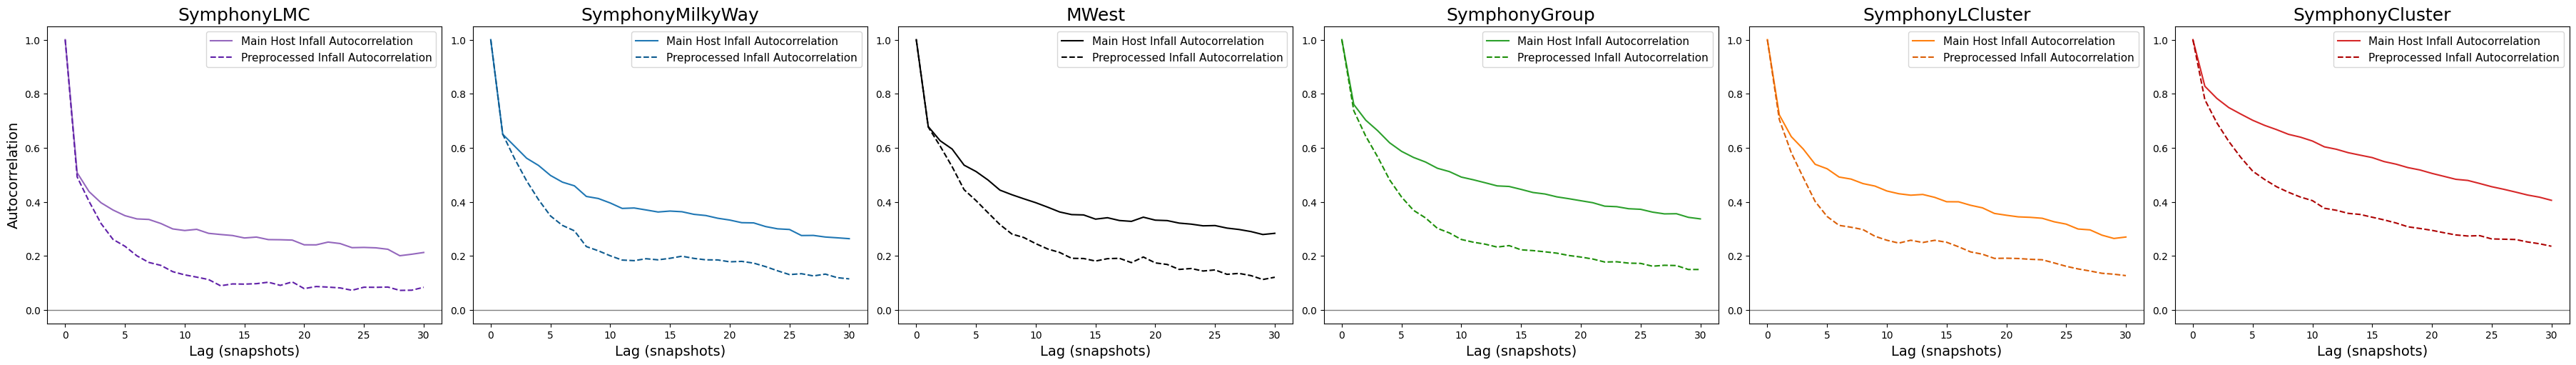

In [25]:
fig, ax = make_autocorrelation_figure(suite_data = suite_data, suite_list = suite_list, colors = colors, alt_colors = alt_colors)

plt.savefig("Preliminary Autocorrelations")
plt.show()